In [1]:
# Final Project: Breast Cancer Diagnosis
# Group Members: Md Mahadi Hasan Moon & Md Imran Hossain
# How to run the code: Input the final_notebook.ipynb and Breast_cancer_data.csv in a same folder and then run the code using jupyter notebook.

In [2]:
#import necessary libraries to begin
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

In [3]:
# Load the dataset
data = pd.read_csv("Breast_cancer_data.csv")

# Display the first few rows of the dataset
data.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


In [4]:
# Check for missing values
print("Missing values in the dataset:")
data.info()
data.isnull().sum()

Missing values in the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mean_radius      569 non-null    float64
 1   mean_texture     569 non-null    float64
 2   mean_perimeter   569 non-null    float64
 3   mean_area        569 non-null    float64
 4   mean_smoothness  569 non-null    float64
 5   diagnosis        569 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 26.8 KB


mean_radius        0
mean_texture       0
mean_perimeter     0
mean_area          0
mean_smoothness    0
diagnosis          0
dtype: int64

In [5]:
# Check the number of unique values in each column
data.nunique()

mean_radius        456
mean_texture       479
mean_perimeter     522
mean_area          539
mean_smoothness    474
diagnosis            2
dtype: int64

In [6]:
# Use describe() function to get summary statistics and transpose the result
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
mean_radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
mean_texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
mean_perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
mean_area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000
mean_smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634
diagnosis,569.0,0.627417,0.483918,0.00000,0.00000,1.00000,1.0000,1.0000


In [7]:
# Features that should not have zero as a natural value
features_with_nonzero_natural_value = ['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area', 'mean_smoothness']

# Replace zeros with NaN for selected features
data[features_with_nonzero_natural_value] = data[features_with_nonzero_natural_value].replace(0, np.nan)

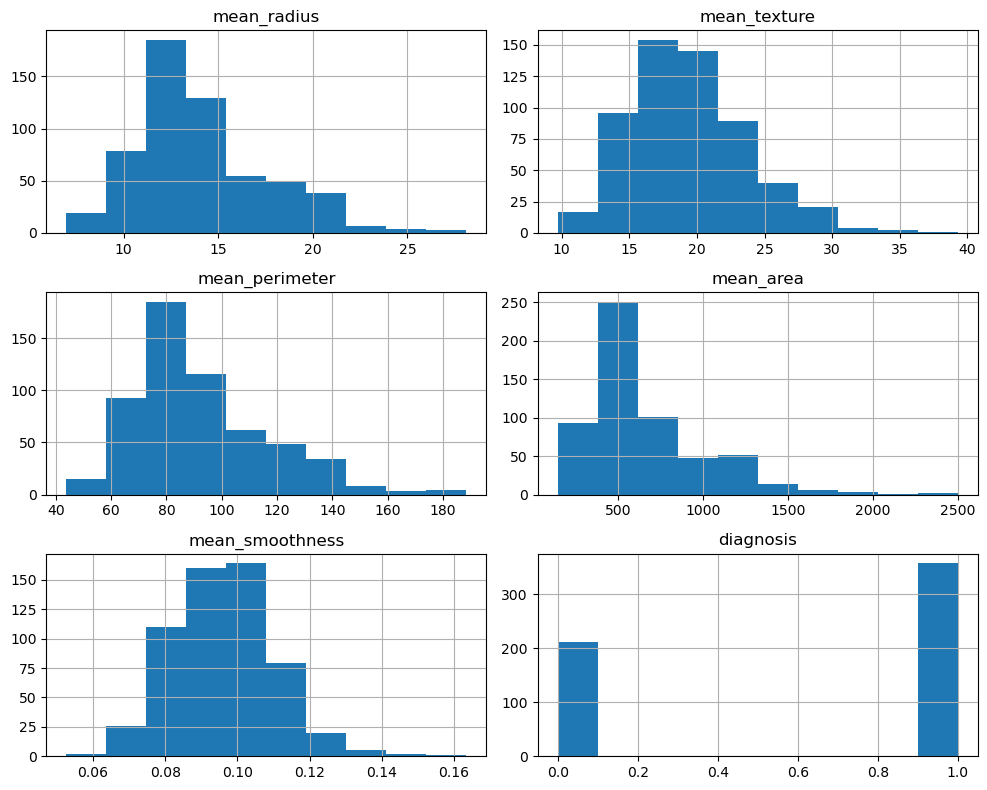

In [8]:
# Plot histograms for each feature
data.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

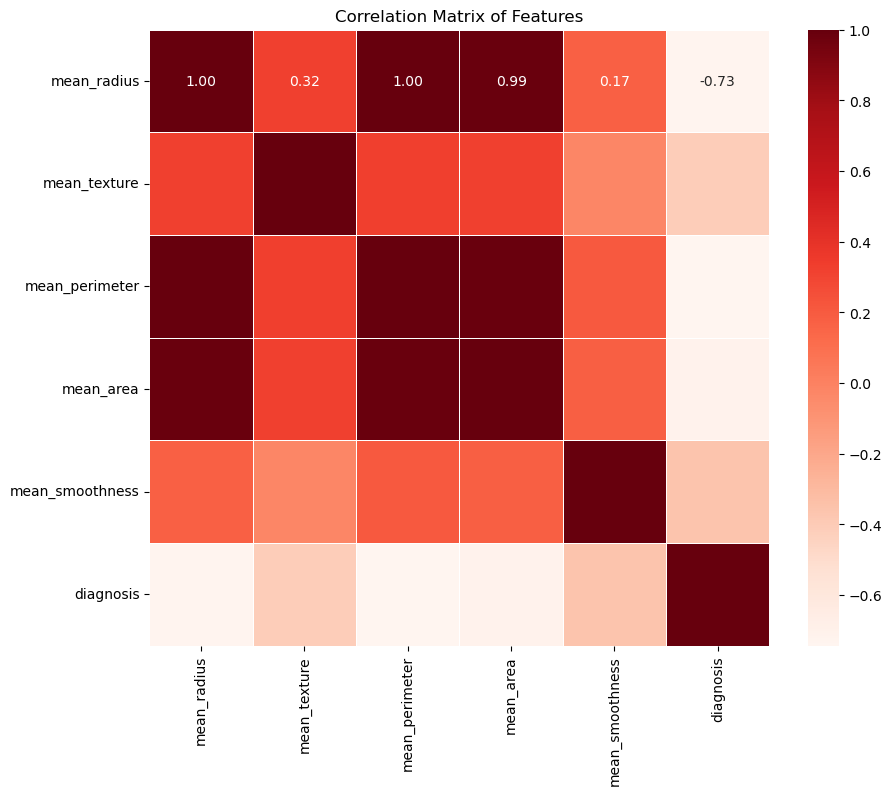

In [9]:
# Compute the correlation matrix
correlation_matrix = data.corr()

# Plot the correlation heatmap with red colormap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='Reds', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.show()


In [10]:
# Split the data into features (X) and target variable (y)
X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# Logistic Regression model
# model with different values of C
param_grid_lr = {'C': [0.001, 0.01, 0.1, 1, 10]}

# Initialize Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)

# Perform grid search to find the best hyperparameters
grid_search_lr = GridSearchCV(log_reg, param_grid_lr, cv=5, scoring='accuracy')
grid_search_lr.fit(X_train, y_train)

# Get the best logistic regression model
best_lr = grid_search_lr.best_estimator_

# Fit the best model to the training data
best_lr.fit(X_train, y_train)

# Make predictions on the testing data
y_pred_lr = best_lr.predict(X_test)

# Calculate accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)

Best Logistic Regression Model:
LogisticRegression(C=10, max_iter=1000)

Accuracy: 0.9473684210526315

Confusion Matrix:
[[40  3]
 [ 3 68]]


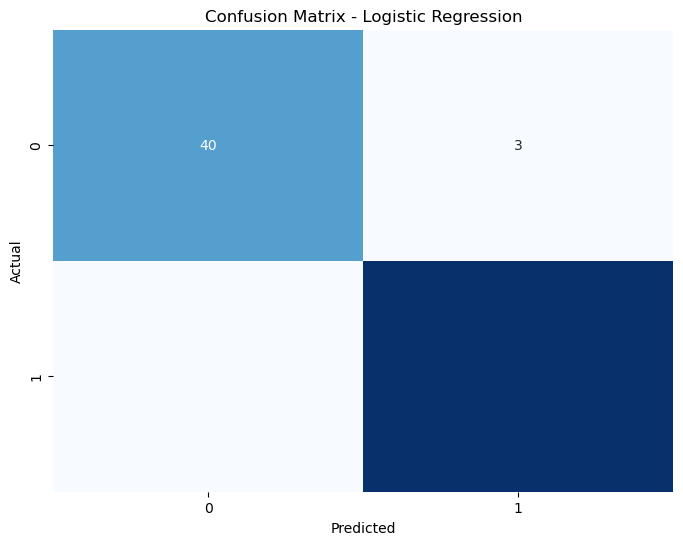

In [12]:
# Generate confusion matrix
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)

print("Best Logistic Regression Model:")
print(best_lr)
print("\nAccuracy:", accuracy_lr)
print("\nConfusion Matrix:")
print(conf_matrix_lr)

# Plot the confusion matrix graphically for LR model
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_lr, annot=True, cmap='Blues', fmt='g', cbar=False)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [13]:
# KNN classifier with different values of n_neighbors
param_grid_knn = {'n_neighbors': list(range(1, 10))}

# Initialize KNN classifier
knn = KNeighborsClassifier()

# Perform grid search to find the best hyperparameters
grid_search_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='accuracy')
grid_search_knn.fit(X_train, y_train)

# Get the best KNN model
best_knn = grid_search_knn.best_estimator_

# Fit the best model to the training data
best_knn.fit(X_train, y_train)

# Make predictions on the testing data
y_pred_knn = best_knn.predict(X_test)

# Calculate accuracy
accuracy_knn = accuracy_score(y_test, y_pred_knn)


Best KNN Model:
KNeighborsClassifier(n_neighbors=9)

Accuracy: 0.9385964912280702

Confusion Matrix:
[[37  6]
 [ 1 70]]


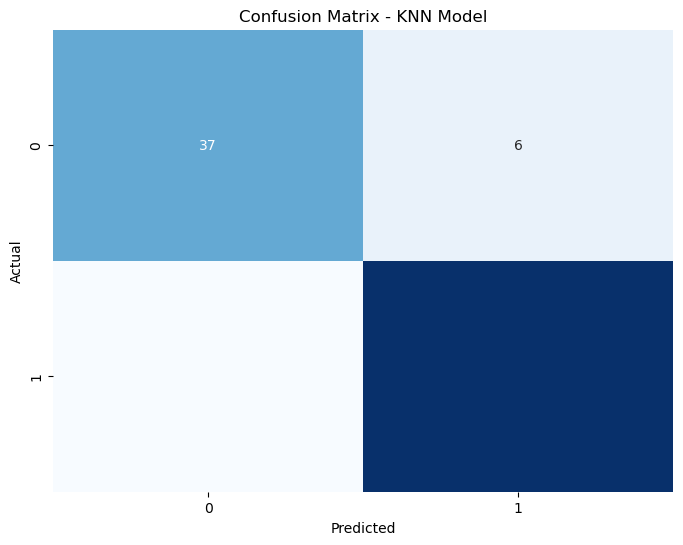

In [14]:
# Generate confusion matrix
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)

print("Best KNN Model:")
print(best_knn)
print("\nAccuracy:", accuracy_knn)
print("\nConfusion Matrix:")
print(conf_matrix_knn)

# Plot the confusion matrix graphically for KNN model
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_knn, annot=True, cmap='Blues', fmt='g', cbar=False)
plt.title('Confusion Matrix - KNN Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [15]:
# Define different values of hyperparameters for hyperparameter tuning
param_grid_nn = {
    'hidden_layer_sizes': [(100,), (50, 50), (50, 50, 50)],
    'activation': ['logistic', 'tanh', 'relu'],
    'max_iter': [500, 1000, 1500]  # Increase max_iter values further
}

# Initialize Neural Network classifier
nn = MLPClassifier()

# Perform grid search to find the best hyperparameters
grid_search_nn = GridSearchCV(nn, param_grid_nn, cv=5, scoring='accuracy')
grid_search_nn.fit(X_train, y_train)

# Get the best Neural Network model
best_nn = grid_search_nn.best_estimator_

# Fit the best model to the training data
best_nn.fit(X_train, y_train)

# Make predictions on the testing data
y_pred_nn = best_nn.predict(X_test)

# Calculate accuracy
accuracy_nn = accuracy_score(y_test, y_pred_nn)


Best Neural Network Model:
MLPClassifier(activation='logistic', max_iter=1500)

Accuracy: 0.9035087719298246

Confusion Matrix:
[[35  8]
 [ 3 68]]


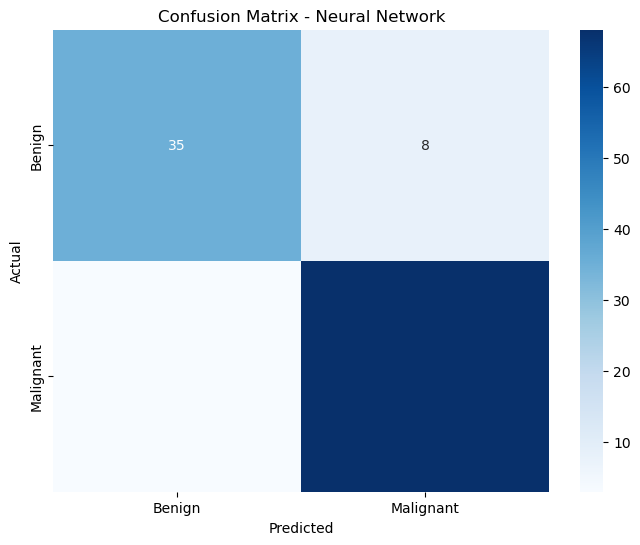

In [16]:
# Generate confusion matrix
conf_matrix_nn = confusion_matrix(y_test, y_pred_nn)

print("Best Neural Network Model:")
print(best_nn)
print("\nAccuracy:", accuracy_nn)
print("\nConfusion Matrix:")
print(conf_matrix_nn)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_nn, annot=True, cmap='Blues', fmt='d', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix - Neural Network')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [17]:
# Multiply accuracies by 100 to convert them into percentage
accuracy_lr_percent = accuracy_lr * 100
accuracy_knn_percent = accuracy_knn * 100
accuracy_nn_percent = accuracy_nn * 100

# Define a dictionary to store models and their accuracies in percentage format
models_accuracy_percent = {
    'Logistic Regression': accuracy_lr_percent,
    'K-Nearest Neighbors': accuracy_knn_percent,
    'Neural Network': accuracy_nn_percent
}

# Create a DataFrame from the dictionary
df_percent = pd.DataFrame(models_accuracy_percent.items(), columns=['Model', 'Accuracy (%)'])

# Display the DataFrame
df_percent

,Model,Accuracy (%)
0,Logistic Regression,94.736842
1,K-Nearest Neighbors,93.859649
2,Neural Network,90.350877
